# MULTISPECKLE DECORRELATION MEASUREMENTS


This notebook replicates the measurements from the article *"Massively parallel, real-time multispeckle diffuse correlation spectroscopy using a 500 x 500 SPAD camera"*. The primary results of the article are temporal autocorrelation measurements $g^{(2)}(\tau) = \frac{\langle n(t) n(t+\tau) \rangle}{\langle n(t) \rangle^2}$. 

This notebook measures the autocorrelation function for a maximum of 24 pixels at the same time. We do count rate measurements and spatial autocorrelations to calibrate the equipment. You can find the data files for all test runs in the **../data/raw/decorrelation_24ch** directory. 

The second section of the notebook contains the data analysis. The script prepares the saved data and processes the data to extract the decorrelation times ($\tau_c$) for single pixels and the line sensor average.
Visual plots of the results are included. 

In [2]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from IPython.display import clear_output
import math

## Experimental Parameters

Reference Article Parameters:

**Optical Settings**
* Wavelength: 785 nm
* Power: 1 nW

**Sensor Geometry**
* Pixel diameter: 6 µm (similar to the speckle diameter)
* Pitch: 16.38 µm
* Fill factor: 10.6%
* Active area: Circular
* Distance (z): 11.5 mm

**Acquisition Settings**
* Photon detection probability (PDP): 15%
* Time bins (n-bins): 16
* Frame rate: 93 fps
* Exposure time: 10.81 µs
* Integration time: 50 ms

In [29]:
# Calibration Parameters
t_exp_ps = 1e9 # exposure time
pixel_pitch_um = 125.0 # um 

# Decorrelation Parameters
t_int_ps = 8e12 # ps (e12 = seconds)
bin_width = 1_000e6 # ps (e6 = micro seconds)
n_bins = 21

## Initialization: Time Taggers and Synchronizer

In [83]:
# Free previusly used tagger (if any)
tt.freeTimeTagger(tagger)

In [3]:
# Create Tagger Object and define available channels
print(f"Serial Numbers:{tt.scanTimeTagger()}") # Extract serial numbers
tagger = tt.createTimeTagger() # Create time tagger
spad_channels = np.array(tagger.getChannelList()) # Available Channels
spad_channels = spad_channels[spad_channels > 0] # Keep rising edges only (positive ch)

print(f"{len(spad_channels)} Available Channels : {spad_channels}") # Extract Channel List

Serial Numbers:('2441001EA1', '2440001E7R')
36 Available Channels : [101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218]


## Calibration: Live Countrate

Monitor interrupted.


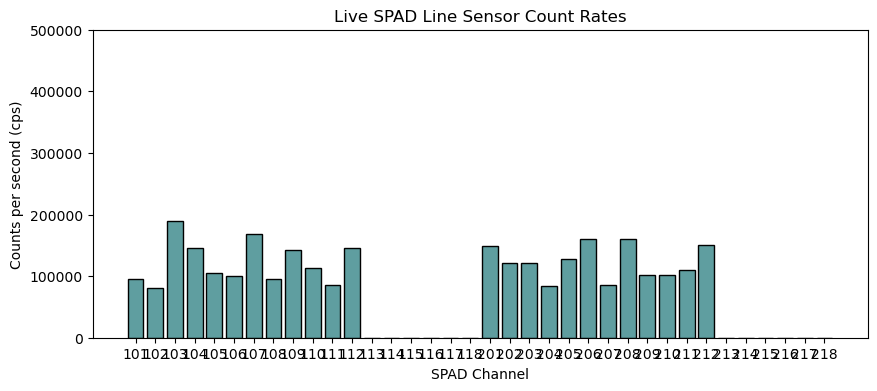

In [13]:
# block uses: t_exp_ps
# Create Countrate object
cr = tt.Countrate(tagger, channels=spad_channels)

channel_labels = [str(ch) for ch in spad_channels]

try:
    for _ in range(1000): #Define number of updates
        # Measure Countrates from object
        cr.startFor(t_exp_ps,clear=True)
        cr.waitUntilFinished()
        rates = cr.getData()
        #Visualize (Histogram)
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.bar(channel_labels, rates, color='cadetblue', edgecolor='black')
        plt.ylim(0,0.5e6) # Adjust limit to expected countrates
        plt.title("Live SPAD Line Sensor Count Rates")
        plt.xlabel("SPAD Channel")
        plt.ylabel("Counts per second (cps)")
        plt.xticks(channel_labels)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
except KeyboardInterrupt:
    print("Monitor interrupted.")

## Calibration: Speckle Size

--- Speckle Size Calibration Results ---
100-Series Row: FWHM = 2.83 pixels | Physical Size = 354.1 µm
200-Series Row: FWHM = 3.98 pixels | Physical Size = 498.1 µm


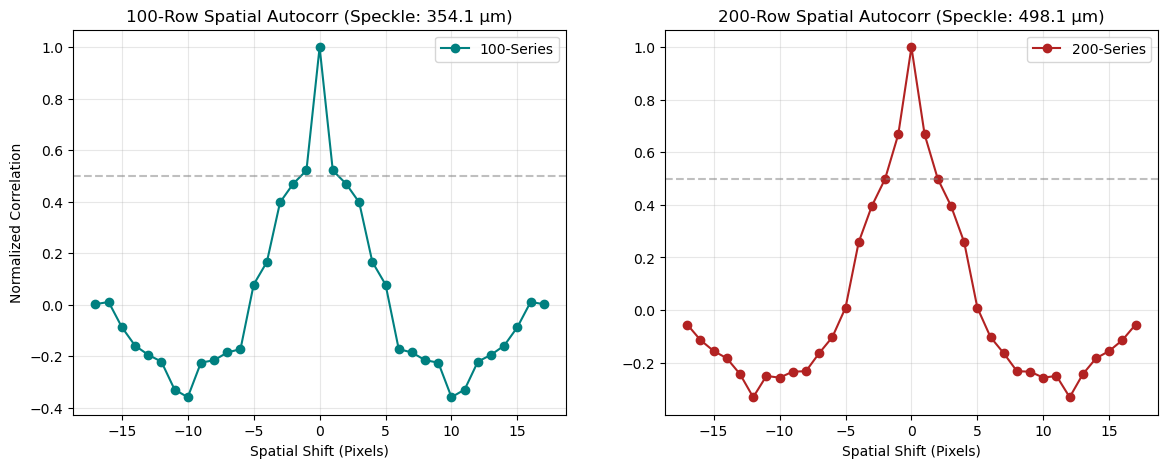

In [12]:
# block uses: t_exp_ps
cr =tt.Countrate(tagger,spad_channels)
cr.startFor(t_exp_ps, clear=True)
cr.waitUntilFinished()
rates = cr.getData()

# Map channels to countrates
rates_map = dict(zip(spad_channels,rates))

# Separate channels 
row_100 = spad_channels[spad_channels<199]
row_200 = spad_channels[spad_channels>199]

# Compute spatial autocorrelation
def spatial_autocorr_with_fwhm(row):
    if len(row) > 0:
        rates = np.array([rates_map[ch] for ch in row])
        fluc = rates - np.mean(rates)
        autocorr = np.correlate(fluc, fluc, mode='full')

        if np.max(autocorr) > 0:
            autocorr = autocorr / np.max(autocorr)

        shifts = np.arange(-len(row) + 1, len(row))
        
        # FWHM Calculation
        above_half = np.where(autocorr >= 0.5)[0]    # indices where the correlation is above 0.5
        
        if len(above_half) > 0:
            # Left crossing interpolation
            left_idx = above_half[0]
            if left_idx > 0:
                x0, x1 = shifts[left_idx - 1], shifts[left_idx]
                y0, y1 = autocorr[left_idx - 1], autocorr[left_idx]
                left_cross = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
            else:
                left_cross = shifts[left_idx]

            # Right crossing interpolation
            right_idx = above_half[-1]
            if right_idx < len(autocorr) - 1:
                x0, x1 = shifts[right_idx], shifts[right_idx + 1]
                y0, y1 = autocorr[right_idx], autocorr[right_idx + 1]
                right_cross = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
            else:
                right_cross = shifts[right_idx]

            fwhm_pixels = right_cross - left_cross
        else:
            fwhm_pixels = 0.0

        return autocorr, shifts, fwhm_pixels
    else:
        print("Error: Empty row provided.")
        return None, None, 0.0

# Extract data and FWHM
autocorr_100, shifts_100, fwhm_100 = spatial_autocorr_with_fwhm(row_100)
autocorr_200, shifts_200, fwhm_200 = spatial_autocorr_with_fwhm(row_200)

# Calculate physical speckle sizes
speckle_size_100_um = fwhm_100 * pixel_pitch_um
speckle_size_200_um = fwhm_200 * pixel_pitch_um

print(f"--- Speckle Size Calibration Results ---")
print(f"100-Series Row: FWHM = {fwhm_100:.2f} pixels | Physical Size = {speckle_size_100_um:.1f} µm")
print(f"200-Series Row: FWHM = {fwhm_200:.2f} pixels | Physical Size = {speckle_size_200_um:.1f} µm")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if autocorr_100 is not None:
    ax1.plot(shifts_100, autocorr_100, marker='o', color='teal', label='100-Series')
    ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f"100-Row Spatial Autocorr (Speckle: {speckle_size_100_um:.1f} µm)")
    ax1.set_xlabel("Spatial Shift (Pixels)")
    ax1.set_ylabel("Normalized Correlation")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

if autocorr_200 is not None:
    ax2.plot(shifts_200, autocorr_200, marker='o', color='firebrick', label='200-Series')
    ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax2.set_title(f"200-Row Spatial Autocorr (Speckle: {speckle_size_200_um:.1f} µm)")
    ax2.set_xlabel("Spatial Shift (Pixels)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.show()

## Decorrelation

In [15]:
# Define Functions
def measure_and_plot_pairs(tagger, target_pairs, integration_time_ps, bin_width=10, n_bins=10000):
    """
    Measures the correlation for a list of SPAD pairs simultaneously and plots them.
    
    Parameters:
    - tagger: The active Swabian TimeTagger instance.
    - target_pairs: List of tuples, e.g., [(1, 2), (1, 12), (1, 24)].
    - integration_time_sec: Measurement duration in seconds.
    - bin_width: Histogram bin width in ps.
    - n_bins: Total number of bins. (10,000 bins * 10ps = +/- 50 ns window)
    """
    
    correlation_objects = {}
    measurement_results = {}
    
    print(f"Starting parallel measurement for {len(target_pairs)} pairs...")
    print(f"Integration time: {integration_time_ps} ps. Hardware clock running...")

    try:
        # Initialize Measurements
        for pair in target_pairs:
            ch_A, ch_B = pair
            corr = tt.Correlation(tagger, ch_A, ch_B, binwidth=bin_width, n_bins=n_bins)
            correlation_objects[pair] = corr
            
            # Start hardware clock asynchronously
            corr.startFor(integration_time_ps, clear=True)

        # Extract Data 
        for pair, corr in correlation_objects.items():
            # Synchronize Python script with hardware completion
            corr.waitUntilFinished()
            
            hist = corr.getData()
            t_axis = corr.getIndex()
            
            measurement_results[pair] = {
                'time': t_axis,
                'histogram': hist
            }
            
        print("Data extracted. Generating plots...")

        # Plot
        num_plots = len(target_pairs)
        cols = min(3, num_plots) # Create a clean grid (max 3 columns wide)
        rows = math.ceil(num_plots / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
        axes = np.atleast_1d(axes).flatten()

        for idx, pair in enumerate(target_pairs):
            ax = axes[idx]
            ch_A, ch_B = pair
            t_axis = measurement_results[pair]['time']
            hist = measurement_results[pair]['histogram']
            
            # Smart formatting based on the pair relationship
            if ch_A == ch_B:
                color = 'cadetblue'
                title = f"Auto-correlation ({ch_A})"
                # Mask out the delta spike at tau=0 for autocorrelations only
                #mask = (t_axis > 1000) | (t_axis < -1000)
                #t_plot, hist_plot = t_axis[mask], hist[mask]
                t_plot, hist_plot = t_axis, hist
            elif abs(ch_A - ch_B) == 1:
                color = 'firebrick'
                title = f"Neighboring Pixels ({ch_A}, {ch_B})"
                t_plot, hist_plot = t_axis, hist
            else:
                color = 'navy'
                title = f"Distant Pixels ({ch_A}, {ch_B})"
                t_plot, hist_plot = t_axis, hist
            
            # Find the baseline by averaging the tail end of the histogram (last 10%)
            tail_length = int(len(hist_plot) * 0.1)
            baseline_avg = np.mean(hist_plot[-tail_length:])
            y_min = baseline_avg * 0.90
            y_max = baseline_avg * 1.50

            ax.plot(t_plot, hist_plot, color=color, linewidth=1.5, label=f'Pair {ch_A}-{ch_B}')
            ax.set_ylim([y_min, y_max])
            ax.set_yscale('log')
            #ax.set_xlim(t_plot[int(len(t_plot)/2)+1],t_plot[-1])
            #ax.set_ylim(hist_plot[-1]*0.5  ,  hist_plot[int(len(hist_plot)/2)+1]*1.5)
            ax.set_title(title)
            ax.set_xlabel("Delay $\\tau$ (ps)")
            ax.set_ylabel("Coincidences")
            ax.grid(True, alpha=0.3)
            ax.legend()
            
        # Hide any unused subplots
        for i in range(num_plots, len(axes)):
            axes[i].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
        return measurement_results

    except Exception as e:
        print(f"An error occurred during measurement: {e}")
        return None

def save_measurement_run(results, data_folder, run_label="diffuser_run"):
    """
    Saves the correlation measurement dictionary to compressed Numpy files.
    Appends a precise timestamp to prevent overwriting previous runs.
    """
    # Create the folder if it doesn't exist
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)
    
    
    print(f"Saving {len(results)} measurement pairs...")
    
    saved_files = []
    for pair, data in results.items():
        ch_A, ch_B = pair
        
        # Format: g2_[ChA]_[ChB]_[Label]_[Timestamp].npz
        filename = f"{data_folder}/g2_{ch_A}_{ch_B}_{run_label}.npz"
        
        # Save arrays and metadata together
        np.savez_compressed(filename, 
                            time=data['time'], 
                            histogram=data['histogram'], 
                            ch_A=ch_A, 
                            ch_B=ch_B)
        
        saved_files.append(filename)
        print(f"  -> Saved: {filename}")
        
    print(f"Run saved successfully in '{data_folder}/'")
    return None

Starting parallel measurement for 24 pairs...
Integration time: 8000000000000.0 ps. Hardware clock running...
Data extracted. Generating plots...


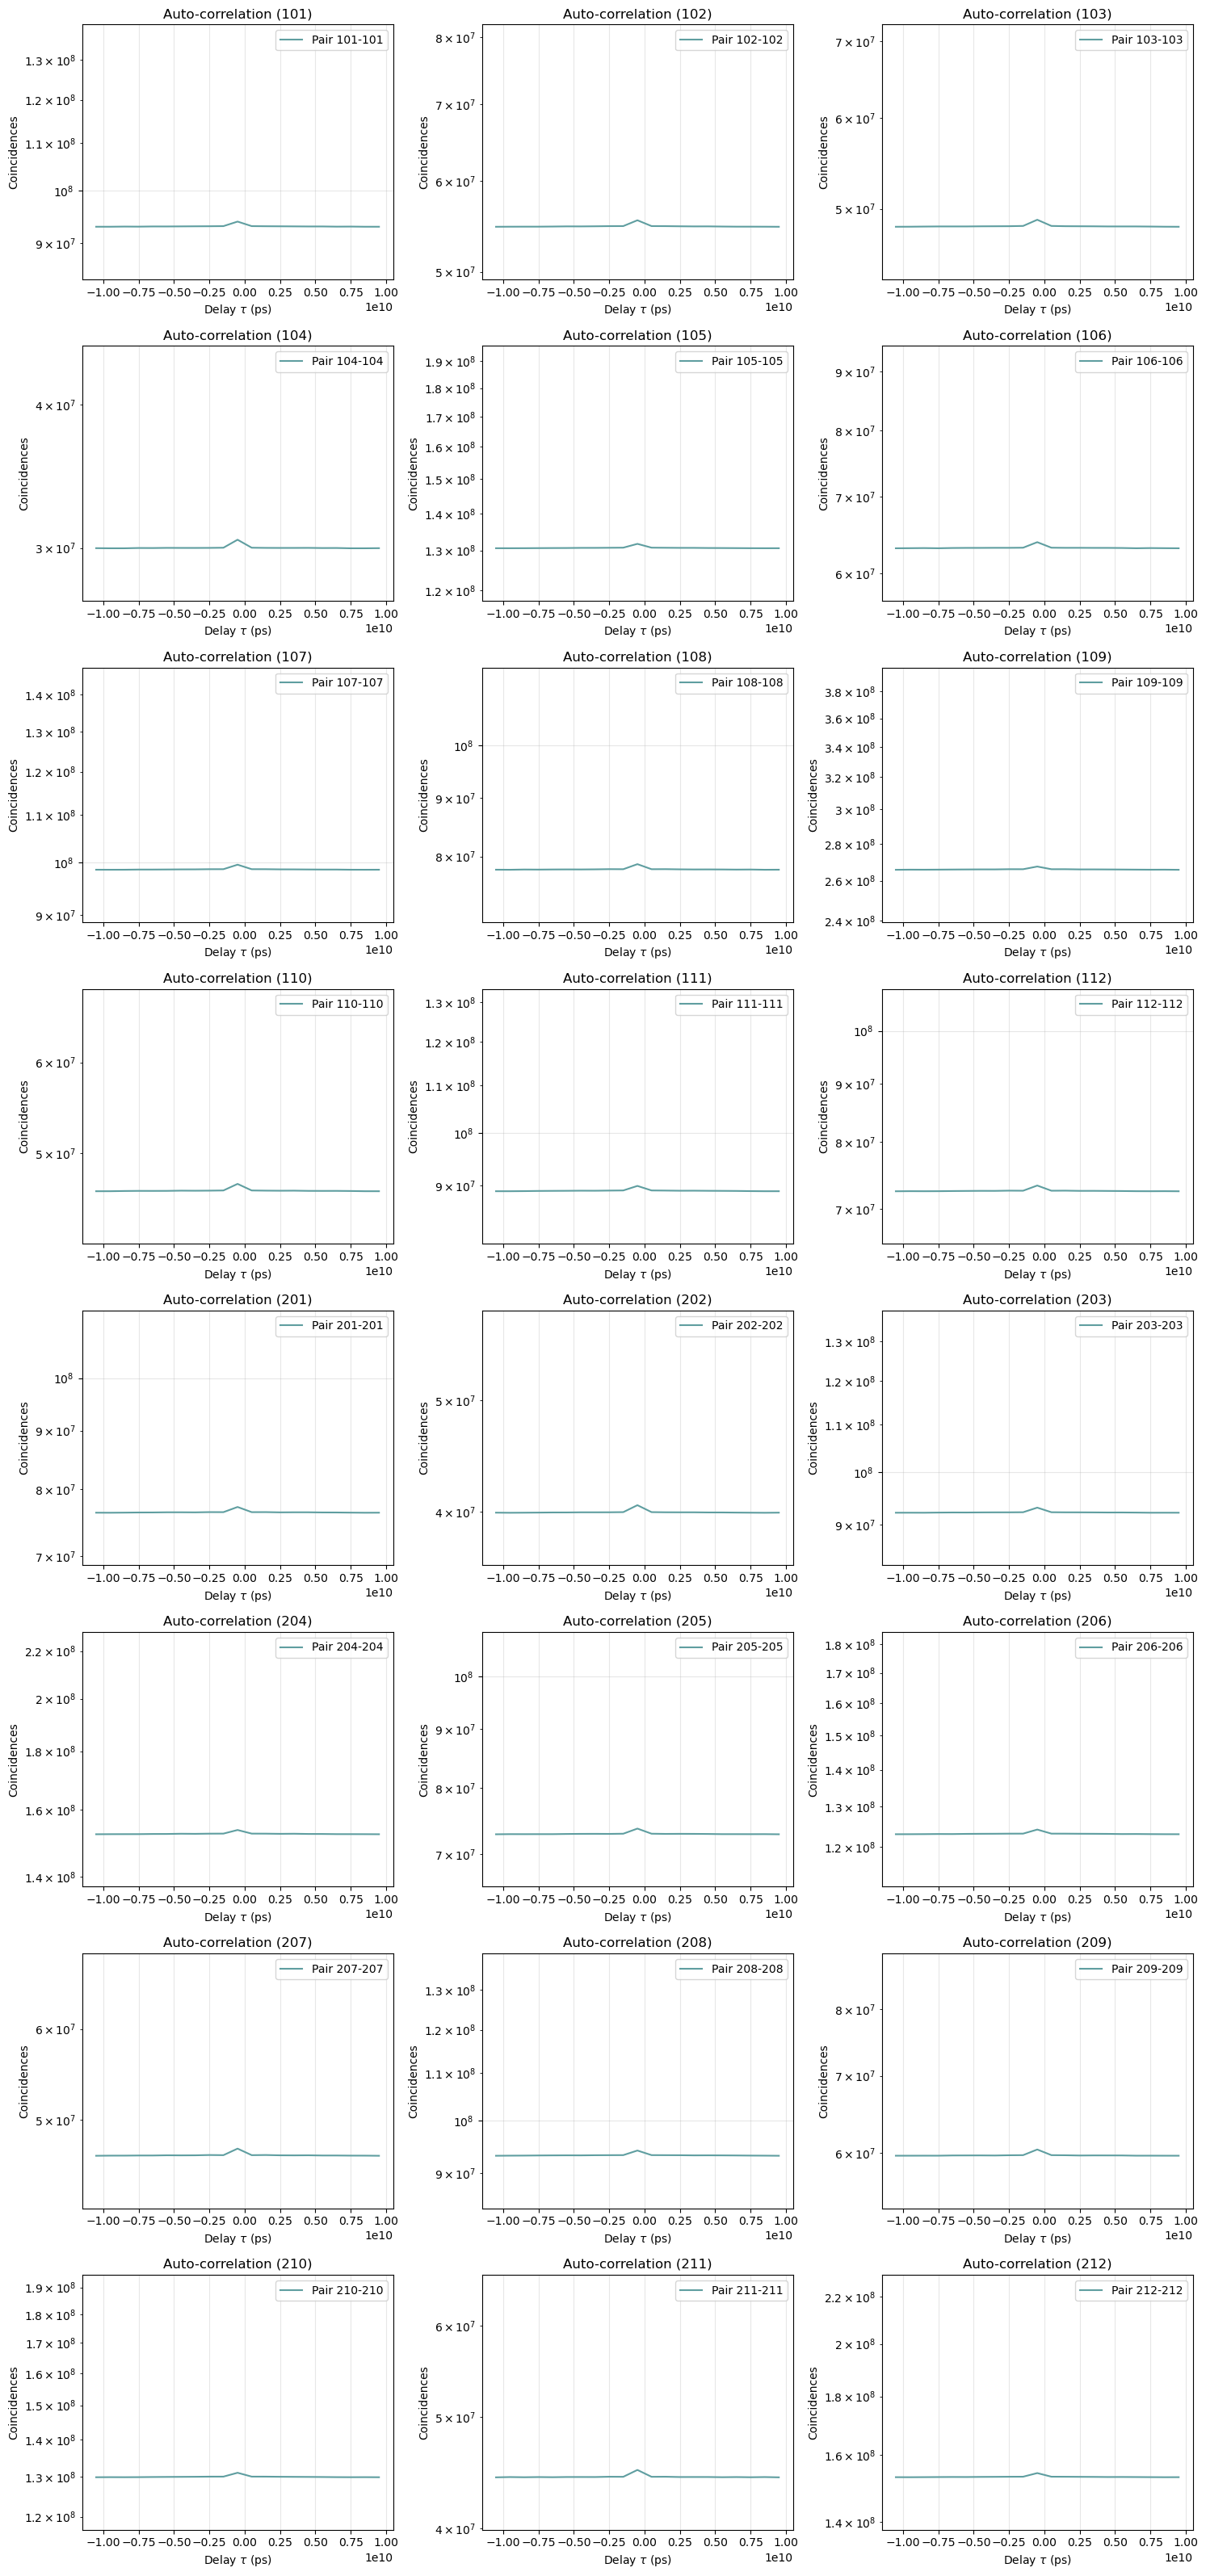

In [79]:
# Run functions
# block uses: t_int_ps, bin_width, n_bins, tagger.

# Define the payload: Compare pixel 12 against distant pixels
payload = [
    ( 101, 101 ),
    ( 102, 102 ),
    ( 103, 103 ),
    ( 104, 104 ),
    ( 105, 105 ),
    ( 106, 106 ),
    ( 107, 107 ),
    ( 108, 108 ),
    ( 109, 109 ),
    ( 110, 110 ),
    ( 111, 111 ),
    ( 112, 112 ),
    ( 201, 201 ),
    ( 202, 202 ),
    ( 203, 203 ),
    ( 204, 204 ),
    ( 205, 205 ),
    ( 206, 206 ),
    ( 207, 207 ),
    ( 208, 208 ),
    ( 209, 209 ),
    ( 210, 210 ),
    ( 211, 211 ),
    ( 212, 212 ),  
]

#payload = [(101,101),(212,212)]

# Run the function
results = measure_and_plot_pairs(tagger, 
                                 target_pairs= payload, 
                                 integration_time_ps=t_int_ps, 
                                 bin_width=bin_width, 
                                 n_bins=n_bins)

In [82]:
# Save the data
run_time = save_measurement_run(results, run_label="24ch-150kcps-S3pix-785nm-CW-diff0degsec", data_folder="../data/raw/decorrelation_24ch/spad_line_data_run8")

Saving 24 measurement pairs...
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_101_101_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_102_102_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_103_103_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_104_104_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_105_105_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_106_106_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_107_107_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/decorrelation_24ch/spad_line_data_run8/g2_108_108_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
  -> Saved: ../data/raw/d

# DATA ANALYSIS
1) Data cleaning 
2) Individual Pixel Analysis
3) Averaged Pixel Analysis

In [25]:
# Import Packages
import numpy as np
import matplotlib.pyplot as plt
import os 
import glob
from scipy.optimize import curve_fit

In [37]:
# Import Data and Filter
data_dir = "../data/raw/decorrelation_24ch/spad_line_data_run10"
speed = 5
spad_channels = np.append(range(101, 113), range(201, 213)) # run 5 to run_10
#spad_channels = [101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212]
#spad_channels = np.append(range(101, 105), range(201, 213)) # run_4

files_pattern = os.path.join(data_dir,"*.npz") # Fetch all the .npz files inside the run
files_list = glob.glob(files_pattern)
print(f"{len(files_list)} files found:")
print('\n'.join([os.path.basename(f) for f in files_list]))

96 files found:
g2_101_101_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
g2_101_101_24ch-150kcps-S3pix-785nm-CW-diff10degsec.npz
g2_101_101_24ch-150kcps-S3pix-785nm-CW-diff15degsec.npz
g2_101_101_24ch-150kcps-S3pix-785nm-CW-diff5degsec.npz
g2_102_102_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
g2_102_102_24ch-150kcps-S3pix-785nm-CW-diff10degsec.npz
g2_102_102_24ch-150kcps-S3pix-785nm-CW-diff15degsec.npz
g2_102_102_24ch-150kcps-S3pix-785nm-CW-diff5degsec.npz
g2_103_103_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
g2_103_103_24ch-150kcps-S3pix-785nm-CW-diff10degsec.npz
g2_103_103_24ch-150kcps-S3pix-785nm-CW-diff15degsec.npz
g2_103_103_24ch-150kcps-S3pix-785nm-CW-diff5degsec.npz
g2_104_104_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
g2_104_104_24ch-150kcps-S3pix-785nm-CW-diff10degsec.npz
g2_104_104_24ch-150kcps-S3pix-785nm-CW-diff15degsec.npz
g2_104_104_24ch-150kcps-S3pix-785nm-CW-diff5degsec.npz
g2_105_105_24ch-150kcps-S3pix-785nm-CW-diff0degsec.npz
g2_105_105_24ch-150kcps-S3pix-785nm-CW-di

C:\Users\Eng Barroso\AppData\Local\Temp\ipykernel_12020\1381102497.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fancybox=True, fontsize=10)


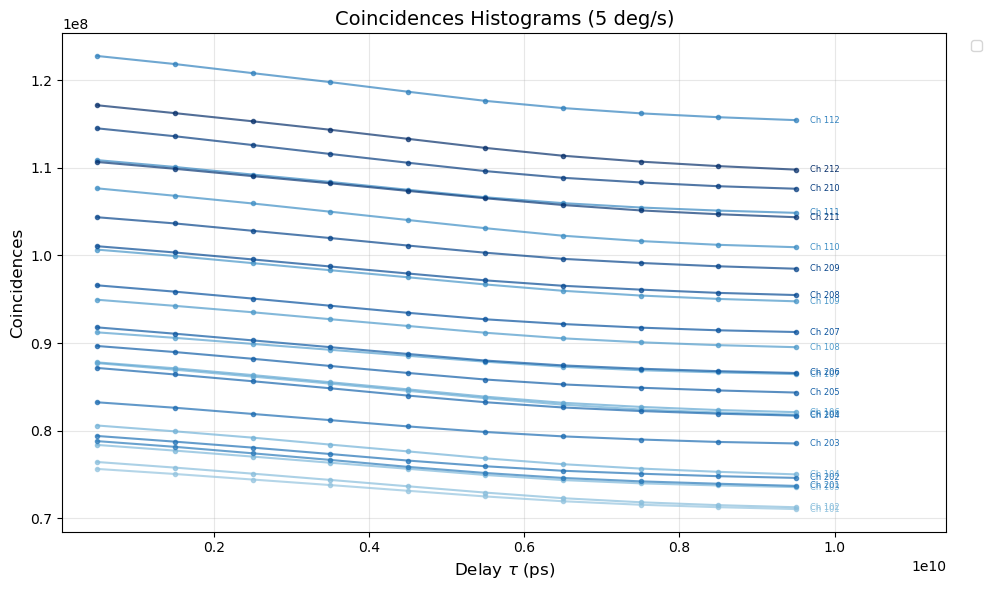

In [38]:
# Create a directory to store data corresponding to a single "speed" for the given "spad_channels"

data_chs ={} # Initialize dictionary

for ch in spad_channels:
    # Extract exact filepath
    file_pattern = os.path.join(data_dir, f"g2_{ch}_{ch}_*diff{speed}degsec.npz") # The '*' wildcard ignores the middle metadata
    file = glob.glob(file_pattern) 
    if not file: 
        print(f"Warning: Data not found for Ch {ch} & Speed {speed}. /n Proceeding without it.")
        continue
    filepath = file[0] 

    # Load Data
    data = np.load(filepath)
    hist = data['histogram']
    tau  = data['time']

    # Filter negative tau bins. 
    valid_indices = tau >= 0
    tau_filtered = tau[valid_indices]
    hist_filtered = hist[valid_indices]

    # Fill dictionary
    data_chs[ch] = { 
        'tau': tau_filtered,
        'counts' : hist_filtered 
    }

# Visualize data
plt.figure(figsize=(10, 6)) # Wider format to accommodate the legend

# Generate a professional blue color gradient for the 24 channels
colors = plt.cm.Blues(np.linspace(0.4, 1, len(spad_channels)))

for idx, (ch, d) in enumerate(data_chs.items()):
    tau_array = d['tau']
    counts_array = d['counts']
    
    # Plot lines with connected dots
    plt.plot(tau_array, counts_array, marker='o', markersize=3, linestyle='-', alpha=0.7, color=colors[idx])  
    
    # Add inline text labels at the end of each curve
    if len(tau_array) > 0:
        last_tau = tau_array[-1]
        last_count = counts_array[-1]
        plt.text(last_tau * 1.02, last_count, f"Ch {ch}", color=colors[idx], fontsize=6, va='center')

# Expand the x-axis limit to make room for the inline text labels
ax = plt.gca()
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max * 1.15)

plt.title(f"Coincidences Histograms ({speed} deg/s)", fontsize=14)
plt.xlabel("Delay $\\tau$ (ps)", fontsize=12)
plt.ylabel("Coincidences", fontsize=12)
plt.grid(True, alpha=0.3)

# Move legend outside, organized in 2 columns
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fancybox=True, fontsize=10)
plt.tight_layout() 
plt.show()

In [39]:
# Functions for data processing
def g2_model(tau, baseline, beta, tau_c): # Ballistic Model
    """
    Theoretical g2 curve (Ballistic Model)
    """
    tau_float = np.asarray(tau, dtype=float)
    tau_c_float = float(tau_c)

    return baseline + beta * np.exp(- (tau_float**2) / (tau_c_float**2))

def fit_g2_curve(tau, counts):
    """
    Fit the g2 model to the input data.

    Parameters: 
    - tau: 1D array
    - counts: 1D array

    Returns: 
    - popt: Optimized parameters [baseline, beta, tau_c].
    """
    # Calculate initial parameter guesses
    tail_length = max(1, int(len(counts) * 0.1)) # Mean of the last 10%
    baseline_guess = np.mean(counts[-tail_length:])
    
    peak_guess = np.max(counts)
    beta_guess = peak_guess - baseline_guess
        
    # Find the tau_c guess at the 1/e decay point
    threshold = baseline_guess + (beta_guess * np.exp(-1))
    
    try:
        decay_idx = np.where(counts < threshold)[0][0]
        tau_c_guess = tau[decay_idx]
    except IndexError:
        tau_c_guess = np.mean(tau) # Fallback if the data is too noisy
        
    initial_guesses = [baseline_guess, beta_guess, tau_c_guess]
    
    try:
        # Remove bounds to allow fitting of both normalized and unnormalized data
        popt, pcov = curve_fit(g2_model, tau, counts, p0=initial_guesses)
    except RuntimeError:
        print("Warning: The curve fit failed. The function will return the initial guesses.")
        popt = initial_guesses
        
    return popt

def normalize(counts):
    """
    Normalizes an array of counts with respect to its baseline in the right tail.

    Parameter: 
    - counts: 1D array
    
    Output: 
    - g2: 1D normalized array.
    """
    tail_length = max(1,int(len(counts)*0.10)) # 10% of array
    baseline = np.mean(counts[-tail_length:]) # Last indices

    if baseline > 0:
        g2 = counts / baseline
    else:
        g2 = counts
        print("Can't normalize with baseline = 0, returning unormalized data.")
    return g2


--- Single Pixel Analysis (Channel 201) ---
Baseline : 0.9996
Beta     : 0.0680
Tau_c    : 4940.99 µs


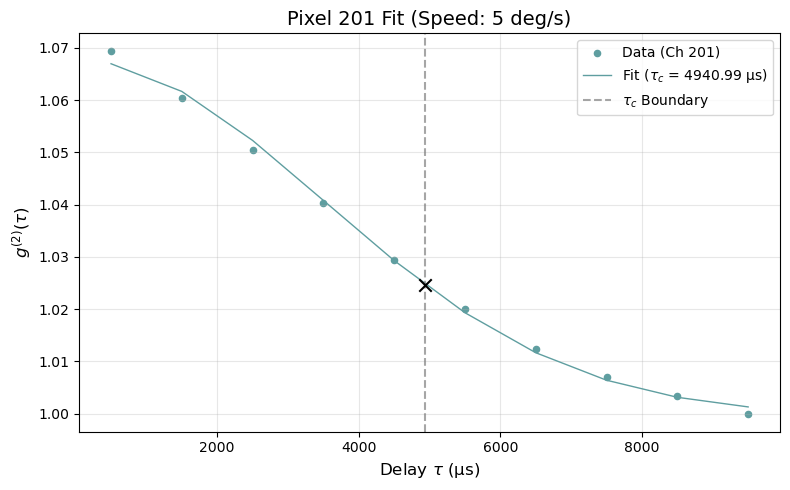

In [40]:
# Single Pixel Analysis
target_ch = 201 # Select pixel to analyze

# Load single pixel data
tau = data_chs[target_ch]["tau"]
counts = data_chs[target_ch]["counts"]

# Normalize 
g2 = normalize(counts)

# Fit parameters
popt = fit_g2_curve(tau, g2)

# Extract and print parameters
fit_baseline = popt[0]
fit_beta = popt[1]
tau_c = popt[2]

# Print Results
tau_c_us = tau_c / 1e6  # Convert to microseconds
print(f"--- Single Pixel Analysis (Channel {target_ch}) ---")
print(f"Baseline : {fit_baseline:.4f}")
print(f"Beta     : {fit_beta:.4f}")
print(f"Tau_c    : {tau_c_us:.2f} µs")


# Visualize the fit
plt.figure(figsize=(8, 5))
tau_us = tau / 1e6

# Plot normalized data
plt.scatter(tau_us, g2, color='cadetblue', alpha=1, s=20, label=f"Data (Ch {target_ch})")

# Plot the mathematical fit
fit_line = g2_model(tau, fit_baseline, fit_beta, tau_c)
plt.plot(tau_us, fit_line, '-', color='cadetblue', linewidth=1, label=f"Fit ($\\tau_c$ = {tau_c_us:.2f} µs)")

# Calculate Y-value at tau_c to plot the marker accurately
tau_c_y = g2_model(tau_c, fit_baseline, fit_beta, tau_c)

# Add a vertical boundary line and an 'x' marker for tau_c
plt.axvline(x=tau_c_us, color='gray', linestyle='--', alpha=0.7, label=f"$\\tau_c$ Boundary")
plt.scatter([tau_c_us], [tau_c_y], color='black', marker='x', s=80, zorder=5)

plt.title(f"Pixel {target_ch} Fit (Speed: {speed} deg/s)", fontsize=14)
plt.xlabel("Delay $\\tau$ (µs)", fontsize=12)
plt.ylabel("$g^{(2)}(\\tau)$", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10, fancybox=True)
plt.tight_layout()
plt.show()

In [41]:
# Individual pixels decorrelation times

tau_c_dict = {} # Make a dictionary to keep the results

for ch, d in data_chs.items():
    tau = d['tau']
    counts = d['counts']
    
    # Normalize the data and calculate the fit
    g2_ind = normalize(counts)
    popt_ind = fit_g2_curve(tau, g2_ind)
    
    # Extract tau_c and change to microseconds
    tau_c_us = popt_ind[2] / 1e6
    tau_c_dict[ch] = tau_c_us
    
    print(f"Ch {ch} \t tau_c: {tau_c_us:.2f} µs")

# Calculate the mean of all individual tau_c values
mean_tau_c = np.mean(list(tau_c_dict.values()))
print(f"----------------------------------------")
print(f"Mean tau_c (all pixels): {mean_tau_c:.2f} µs\n")

Ch 101 	 tau_c: 5207.29 µs
Ch 102 	 tau_c: 5291.42 µs
Ch 103 	 tau_c: 4981.79 µs
Ch 104 	 tau_c: 5346.15 µs
Ch 105 	 tau_c: 5281.07 µs
Ch 106 	 tau_c: 5203.29 µs
Ch 107 	 tau_c: 5042.14 µs
Ch 108 	 tau_c: 5124.05 µs
Ch 109 	 tau_c: 5305.35 µs
Ch 110 	 tau_c: 5292.67 µs
Ch 111 	 tau_c: 5045.88 µs
Ch 112 	 tau_c: 5090.56 µs
Ch 201 	 tau_c: 4940.99 µs
Ch 202 	 tau_c: 4856.66 µs
Ch 203 	 tau_c: 4859.63 µs
Ch 204 	 tau_c: 4906.37 µs
Ch 205 	 tau_c: 4879.94 µs
Ch 206 	 tau_c: 4844.97 µs
Ch 207 	 tau_c: 4828.06 µs
Ch 208 	 tau_c: 5071.59 µs
Ch 209 	 tau_c: 5152.46 µs
Ch 210 	 tau_c: 4978.72 µs
Ch 211 	 tau_c: 5465.72 µs
Ch 212 	 tau_c: 5451.41 µs
----------------------------------------
Mean tau_c (all pixels): 5102.01 µs



Number of averaged pixels : 24
Baseline                  : 0.9989
Beta                      : 0.0632
Tau_c                     : 5101.47 µs
STD of g2 functions       : 0.004473866990598759 


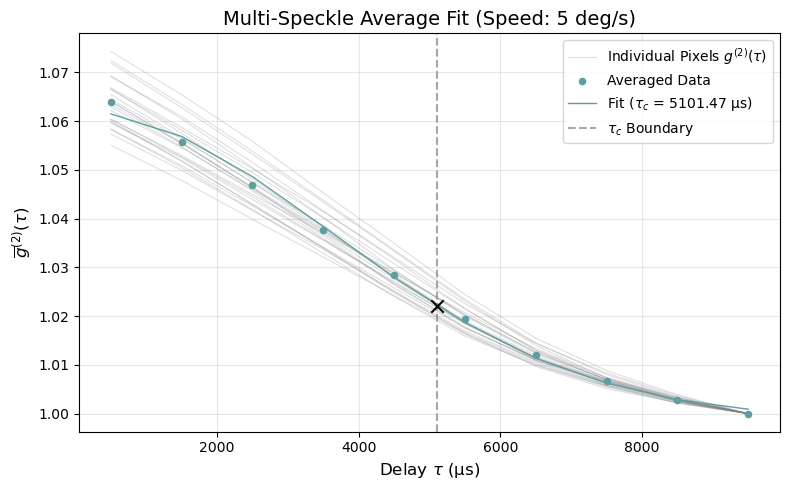

In [42]:
# Multi-Speckle Average Analysis

# Extract tau and counts
tau = list(data_chs.values())[0]['tau']
all_counts = [d['counts'] for d in data_chs.values()]

# Calculate g2 averaged
#avg_counts = np.mean(all_counts, axis=0)    # Average counts of all pixels
#avg_g2 = normalize(avg_counts)  # Normalize the averaged data
g2 = [normalize(d['counts']) for d in data_chs.values()]
avg_g2 = np.mean(g2, axis=0)

# Calculate the standard deviation across individual g2
std_counts = np.std(g2, axis=0)
target_bin_std = std_counts[1]

# Curve fit
popt_avg = fit_g2_curve(tau, avg_g2)

fit_baseline_avg = popt_avg[0]
fit_beta_avg = popt_avg[1]
tau_c_avg = popt_avg[2]
tau_c_avg_us = tau_c_avg / 1e6

print(f"Number of averaged pixels : {len(data_chs)}")
print(f"Baseline                  : {fit_baseline_avg:.4f}")
print(f"Beta                      : {fit_beta_avg:.4f}")
print(f"Tau_c                     : {tau_c_avg_us:.2f} µs")
print(f"STD of g2 functions       : {target_bin_std} ")

# Plot
plt.figure(figsize=(8, 5))

# Plot individual normalized g_2 curves in the background
label_added = False
for ch, d in data_chs.items():
    g2_ind = normalize(d['counts'])
    if not label_added:
        plt.plot(tau_us, g2_ind, '-', color='gray', alpha=0.25, linewidth=0.8, label="Individual Pixels $g^{(2)}(\\tau)$")
        label_added = True
    else:
        plt.plot(tau_us, g2_ind, '-', color='gray', alpha=0.25, linewidth=0.8)

# Plot the normalized averaged data
plt.scatter(tau_us, avg_g2, color='cadetblue', alpha=1, s=20, zorder=3, label="Averaged Data")

# Plot the mathematical fit
fit_line_avg = g2_model(tau, fit_baseline_avg, fit_beta_avg, tau_c_avg)
plt.plot(tau_us, fit_line_avg, '-', color='cadetblue', linewidth=1, zorder=4, label=f"Fit ($\\tau_c$ = {tau_c_avg_us:.2f} µs)")

# Calculate Y-value at tau_c_avg to plot the marker accurately
tau_c_avg_y = g2_model(tau_c_avg, fit_baseline_avg, fit_beta_avg, tau_c_avg)

# Add a vertical boundary line and an 'x' marker for tau_c_avg
plt.axvline(x=tau_c_avg_us, color='gray', linestyle='--', alpha=0.7, zorder=1, label=f"$\\tau_c$ Boundary")
plt.scatter([tau_c_avg_us], [tau_c_avg_y], color='black', marker='x', s=80, zorder=5)

try:
    plt.title(f"Multi-Speckle Average Fit (Speed: {speed} deg/s)", fontsize=14)
except NameError:
    plt.title("Multi-Speckle Average Fit", fontsize=14)

plt.xlabel("Delay $\\tau$ (µs)", fontsize=12)
plt.ylabel("$\overline{g}^{(2)}(\\tau)$", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10, fancybox=True)
plt.tight_layout()
plt.show()

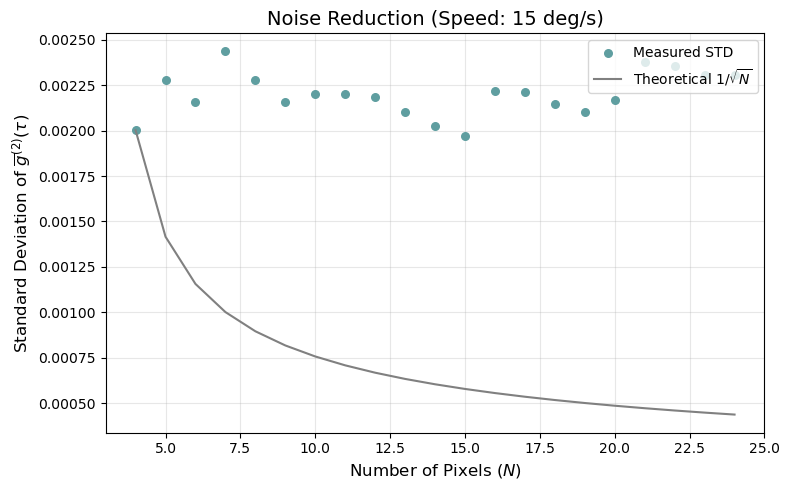

In [24]:
# Standard Deviation for Increasing number of pixels. 
num_pix_list = np.arange(4,len(data_chs)+1)
meas_stdv = []

for n in num_pix_list:
    std_counts = np.std(g2[:n], axis=0)
    n_std = std_counts[0]
    meas_stdv.append(n_std)

# Theoretical curve
theoretical_stdv = meas_stdv[0] / np.sqrt(num_pix_list-num_pix_list[0]+1)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(num_pix_list, meas_stdv, color='cadetblue', alpha=1, s=30, zorder=3, label="Measured STD") # Plot measured standard deviation
plt.plot(num_pix_list, theoretical_stdv, '-', color='gray', linewidth=1.5, zorder=4, label="Theoretical $1/\\sqrt{N}$") # Plot theoretical 1/sqrt(N) fit
plt.title(f"Noise Reduction (Speed: {speed} deg/s)", fontsize=14)
plt.xlabel("Number of Pixels ($N$)", fontsize=12)
plt.ylabel("Standard Deviation of $\\overline{g}^{(2)}(\\tau)$", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10, fancybox=True)
plt.tight_layout()
plt.show()

# FURTHER WORK
* Implement calibration to zero-out delays between channels.
* Buffer Overflaw: For the Time Tagger Ultra, continuous tags streamed can exceed 90 MTags/s, depending on the CPU of the PC the Time Tagger is attached to. Higher data rates for short times are buffered internally, so that no overflow occurs. If continuous higher data rates persist, the internal buffer gets completely filled. Therefore, some of the time tags are discarded and not transferred to the PC, resulting in data loss. The hardware allows you to check with TimeTaggerSource::getOverflows() whether an overflow condition has occurred.

# NOTES
The core of Michaels paper is that the Standard deviation of 500x500 SPAD sensor is lower than that of the indivisual pixels. He shows this by: 
* Measuring  $g^{(2)} (\tau)$ and $\bar{g}^{(2)} (\tau)$ over *160* integration periods. 
* STD is then calculated for a given $\tau$ bin. Paper reports $STD(g^{(2)} (10.8\mu s))=0.123$ and $STD(\bar{g}^{(2)}_{2.5e5} (10.8 \mu s))=2.6e-4$ 
* $SNR(g^{(2)} (\tau)) = mean_{160}(g^{(2)} (\tau)-1) / STD_{160}(g^{(2)} (\tau))$
